# From Group GEMM to MOE Kernels

In this tutorial, we will start from a group GEMM kernel, optimize the kernel for better performance, and then extend it to a Mixture of Experts (MOE) kernel. We will use Triton.

## References:
- [Group GEMM](https://triton-lang.org/main/getting-started/tutorials/08-grouped-gemm.html)
- [Persistent Matmul](https://triton-lang.org/main/getting-started/tutorials/09-persistent-matmul.html)
- [Block Scaled Quantized Matmul](https://triton-lang.org/main/getting-started/tutorials/10-block-scaled-matmul.html)
- [MOE by Applied AI](https://deepwiki.com/pytorch-labs/applied-ai/3.2-mixture-of-experts-(moe))
- vLLM and Sglang's fused moe kernels

## Group GEMM
### Problem definition

A **Group GEMM** is a batch of $G$ independent matrix multiplications that are launched together as a single kernel. Unlike a regular *batched* GEMM, the per-problem shapes $(M_g, N_g, K_g)$ are allowed to differ across the group.

**Inputs**

- A list of left operands $\{A_g\}_{g=0}^{G-1}$, where $A_g \in \mathbb{R}^{M_g \times K_g}$.
- A list of right operands $\{B_g\}_{g=0}^{G-1}$, where $B_g \in \mathbb{R}^{K_g \times N_g}$.
- The group size $G$ (the number of GEMMs).

The shared inner dimension $K_g$ must match between $A_g$ and $B_g$, but $M_g$, $N_g$, $K_g$ may all vary with $g$. Because the matrices have different shapes, they cannot live in a single dense $(G, M, K)$ tensor — they are passed to the kernel as a *device-side array of pointers* together with two metadata tensors:

| tensor | shape | dtype | meaning |
|---|---|---|---|
| `group_a_ptrs`, `group_b_ptrs`, `group_c_ptrs` | `[G]` | `int64` | base address of $A_g$, $B_g$, $C_g$ in global memory |
| `group_gemm_sizes` | `[G, 3]` | `int32` | per-problem $(M_g, N_g, K_g)$ |
| `g_lds` | `[G, 3]` | `int32` | per-problem leading dimensions $(\text{lda}_g, \text{ldb}_g, \text{ldc}_g)$ |

**Output**

- A list of result matrices $\{C_g\}_{g=0}^{G-1}$, where $C_g \in \mathbb{R}^{M_g \times N_g}$.

**Computation**

For each problem $g \in \{0, 1, \dots, G-1\}$, compute the standard matrix product

$$C_g \; = \; A_g \, B_g, \qquad (C_g)_{i j} \; = \; \sum_{k=0}^{K_g-1} (A_g)_{i k}\,(B_g)_{k j}.$$

The $G$ products are mathematically independent — each one is just an ordinary GEMM. The reason to fuse them into a single kernel is purely a **scheduling** concern:

1. **Launch overhead.** Issuing $G$ separate kernels pays the launch cost $G$ times. When the individual problems are small (which is exactly the regime that motivates MoE later in this tutorial), this overhead dominates the actual math.
2. **GPU occupancy.** A single small GEMM may not produce enough output tiles to fill all SMs. Treating the group as one work pool lets tiles from *different* problems run concurrently on different SMs, keeping the device saturated.


We'll start from a non-persistent group GEMM kernel, and then optimize it with persistent threads and other techniques. Finally, we'll extend the kernel to support Mixture of Experts (MOE) workloads.

In [1]:
import torch
import triton

import triton.language as tl

# Check CUDA devices
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current CUDA device: {torch.cuda.current_device()}")
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

CUDA available: True
Number of CUDA devices: 1
Current CUDA device: 0
CUDA device name: NVIDIA A100-SXM4-40GB


### Non-persistent group GEMM

In [2]:
@triton.jit
def find_group(
    block_id,
    group_size,
    group_prefix_blks_ptr,
):
    # Largest i in [0, group_size-1] such that prefix[i] <= block_id.
    # prefix[0] = 0, prefix[i] = sum_{j < i} num_tiles_j.
    l = 0
    r = group_size - 1
    while l < r:
        mid = (l + r + 1) >> 1  # upper-rounding mid avoids l = r - 1 infinite loop
        val = tl.load(group_prefix_blks_ptr + mid)
        if val <= block_id:
            l = mid
        else:
            r = mid - 1
    return l


@triton.jit
def non_persistent_group_gemm(
    group_a_ptrs,            # [G]   int64 base addresses of A_g
    group_b_ptrs,            # [G]
    group_c_ptrs,            # [G]
    group_gemm_sizes_ptr,    # [G, 3] (M_g, N_g, K_g)
    g_lds_ptr,               # [G, 3] (lda_g, ldb_g, ldc_g)
    group_prefix_blks_ptr,   # [G]   prefix[i] = sum_{j<i} num_tiles_j (prefix[0] = 0)
    group_size,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
):
    block_id = tl.program_id(0)

    # Locate which problem this CTA belongs to and its tile within that problem.
    group_id = find_group(block_id, group_size, group_prefix_blks_ptr)
    group_blk_offset = tl.load(group_prefix_blks_ptr + group_id)
    local_block_id = block_id - group_blk_offset

    m = tl.load(group_gemm_sizes_ptr + group_id * 3)
    n = tl.load(group_gemm_sizes_ptr + group_id * 3 + 1)
    k = tl.load(group_gemm_sizes_ptr + group_id * 3 + 2)

    stride_a = tl.load(g_lds_ptr + group_id * 3)
    stride_b = tl.load(g_lds_ptr + group_id * 3 + 1)
    stride_c = tl.load(g_lds_ptr + group_id * 3 + 2)

    num_n_tiles = tl.cdiv(n, BLOCK_SIZE_N)
    tile_m_idx = local_block_id // num_n_tiles
    tile_n_idx = local_block_id % num_n_tiles

    a_ptr = tl.load(group_a_ptrs + group_id).to(tl.pointer_type(tl.bfloat16))
    b_ptr = tl.load(group_b_ptrs + group_id).to(tl.pointer_type(tl.bfloat16))
    c_ptr = tl.load(group_c_ptrs + group_id).to(tl.pointer_type(tl.bfloat16))

    offs_m = tile_m_idx * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offs_n = tile_n_idx * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    offs_k = tl.arange(0, BLOCK_SIZE_K)

    a_ptrs = a_ptr + offs_m[:, None] * stride_a + offs_k[None, :]
    b_ptrs = b_ptr + offs_k[:, None] * stride_b + offs_n[None, :]

    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
    for k_start in range(0, k, BLOCK_SIZE_K):
        k_mask = (k_start + offs_k) < k
        a_mask = (offs_m[:, None] < m) & k_mask[None, :]
        b_mask = k_mask[:, None] & (offs_n[None, :] < n)
        a_tile = tl.load(a_ptrs, mask=a_mask, other=0.0)
        b_tile = tl.load(b_ptrs, mask=b_mask, other=0.0)
        accumulator = tl.dot(a_tile, b_tile, acc=accumulator)
        a_ptrs += BLOCK_SIZE_K
        b_ptrs += BLOCK_SIZE_K * stride_b

    c_ptrs = c_ptr + offs_m[:, None] * stride_c + offs_n[None, :]
    c_mask = (offs_m[:, None] < m) & (offs_n[None, :] < n)
    tl.store(c_ptrs, accumulator.to(tl.bfloat16), mask=c_mask)

In [3]:
def non_persistent_group_gemm_fn(
    group_A,
    group_B,
    BLOCK_SIZE_M: int = 64,
    BLOCK_SIZE_N: int = 64,
    BLOCK_SIZE_K: int = 32,
):
    assert len(group_A) == len(group_B)
    G = len(group_A)
    DEVICE = group_A[0].device

    A_addrs, B_addrs, C_addrs = [], [], []
    g_sizes, g_lds = [], []
    group_C = []
    prefix_blks = [0]  # prefix[0] = 0; prefix[i] = sum_{j<i} num_tiles_j

    for i in range(G):
        A, B = group_A[i], group_B[i]
        assert A.shape[1] == B.shape[0], f"K mismatch at problem {i}: {A.shape} vs {B.shape}"
        M, K = A.shape
        _, N = B.shape
        C = torch.empty((M, N), device=DEVICE, dtype=A.dtype)

        group_C.append(C)
        A_addrs.append(A.data_ptr())
        B_addrs.append(B.data_ptr())
        C_addrs.append(C.data_ptr())
        g_sizes += [M, N, K]
        g_lds += [A.stride(0), B.stride(0), C.stride(0)]

        num_m_tiles = triton.cdiv(M, BLOCK_SIZE_M)
        num_n_tiles = triton.cdiv(N, BLOCK_SIZE_N)
        prefix_blks.append(prefix_blks[-1] + num_m_tiles * num_n_tiles)

    total_blocks = prefix_blks[-1]
    prefix_blks = prefix_blks[:G]  # kernel indexes [0, G-1]

    d_a_ptrs = torch.tensor(A_addrs, device=DEVICE, dtype=torch.int64)
    d_b_ptrs = torch.tensor(B_addrs, device=DEVICE, dtype=torch.int64)
    d_c_ptrs = torch.tensor(C_addrs, device=DEVICE, dtype=torch.int64)
    d_g_sizes = torch.tensor(g_sizes, device=DEVICE, dtype=torch.int32)
    d_g_lds = torch.tensor(g_lds, device=DEVICE, dtype=torch.int32)
    d_prefix = torch.tensor(prefix_blks, device=DEVICE, dtype=torch.int32)

    grid = (total_blocks,)
    non_persistent_group_gemm[grid](
        d_a_ptrs, d_b_ptrs, d_c_ptrs,
        d_g_sizes, d_g_lds,
        d_prefix,
        G,
        BLOCK_SIZE_M=BLOCK_SIZE_M,
        BLOCK_SIZE_N=BLOCK_SIZE_N,
        BLOCK_SIZE_K=BLOCK_SIZE_K,
    )
    return group_C

#### Correctness Check

In [4]:
DEVICE = torch.device("cuda")
DTYPE = torch.bfloat16


def _make_group(ms, ns, ks, dtype=DTYPE, device=DEVICE):
    """Inputs are scaled by 1/sqrt(K) so that output entries have O(1) magnitude,
    keeping comparisons within a few bf16 ulps regardless of K."""
    group_A, group_B = [], []
    for M, N, K in zip(ms, ns, ks):
        scale = K ** -0.5
        group_A.append(torch.randn((M, K), device=device, dtype=dtype) * scale)
        group_B.append(torch.randn((K, N), device=device, dtype=dtype))
    return group_A, group_B


def _check(group_A, group_B, label, atol=2e-2, rtol=2e-2):
    tri_out = non_persistent_group_gemm_fn(group_A, group_B)
    # fp32 reference: removes the differential bf16 rounding between two
    # equally-correct bf16 implementations and pins the comparison to the
    # ideal math.
    ref_out = [torch.matmul(a.float(), b.float()).to(a.dtype)
               for a, b in zip(group_A, group_B)]
    for i, (t, r) in enumerate(zip(tri_out, ref_out)):
        torch.testing.assert_close(t, r, atol=atol, rtol=rtol)
    print(f"[{label}] OK ({len(group_A)} problems)")


torch.manual_seed(0)

# Aligned: multiples of (BM=64, BN=64, BK=32) — pure happy path, no mask edges.
aligned_m = [1024, 512, 256, 128]
aligned_n = [1024, 512, 256, 128]
aligned_k = [1024, 512, 256, 128]
gA, gB = _make_group(aligned_m, aligned_n, aligned_k)
_check(gA, gB, "aligned")

# Irregular: deliberately not multiples of any block size — exercises masking on
# all three of M, N, K, including the K tail.
irreg_m = [1000, 513, 200, 99]
irreg_n = [1000, 257, 200, 99]
irreg_k = [1000, 513, 200, 99]
gA, gB = _make_group(irreg_m, irreg_n, irreg_k)
_check(gA, gB, "irregular")

[aligned] OK (4 problems)
[irregular] OK (4 problems)


#### Auto tuning

In [5]:
import itertools


def _prepare_launch_args(group_A, group_B, BM: int, BN: int):
    """Build the device-side metadata for a launch with given (BM, BN).

    Separated from the kernel call so the benchmark loop can amortize this
    work across many timed runs of the same config.
    """
    G = len(group_A)
    DEVICE = group_A[0].device

    A_addrs, B_addrs, C_addrs = [], [], []
    g_sizes, g_lds = [], []
    group_C = []
    prefix = [0]

    for A, B in zip(group_A, group_B):
        M, K = A.shape
        _, N = B.shape
        C = torch.empty((M, N), device=DEVICE, dtype=A.dtype)
        group_C.append(C)
        A_addrs.append(A.data_ptr())
        B_addrs.append(B.data_ptr())
        C_addrs.append(C.data_ptr())
        g_sizes += [M, N, K]
        g_lds += [A.stride(0), B.stride(0), C.stride(0)]
        prefix.append(prefix[-1] + triton.cdiv(M, BM) * triton.cdiv(N, BN))

    total_blocks = prefix[-1]
    return dict(
        d_a_ptrs=torch.tensor(A_addrs, device=DEVICE, dtype=torch.int64),
        d_b_ptrs=torch.tensor(B_addrs, device=DEVICE, dtype=torch.int64),
        d_c_ptrs=torch.tensor(C_addrs, device=DEVICE, dtype=torch.int64),
        d_g_sizes=torch.tensor(g_sizes, device=DEVICE, dtype=torch.int32),
        d_g_lds=torch.tensor(g_lds, device=DEVICE, dtype=torch.int32),
        d_prefix=torch.tensor(prefix[:G], device=DEVICE, dtype=torch.int32),
        G=G,
        total_blocks=total_blocks,
        group_C=group_C,
    )


def _launch(args, BM, BN, BK, num_warps, num_stages):
    non_persistent_group_gemm[(args["total_blocks"],)](
        args["d_a_ptrs"], args["d_b_ptrs"], args["d_c_ptrs"],
        args["d_g_sizes"], args["d_g_lds"], args["d_prefix"],
        args["G"],
        BLOCK_SIZE_M=BM, BLOCK_SIZE_N=BN, BLOCK_SIZE_K=BK,
        num_warps=num_warps, num_stages=num_stages,
    )


# Candidate configs — same shape of sweep as 08-grouped-gemm's tma_configs,
# but tuned to the non-persistent kernel.
AUTOTUNE_CONFIGS = [
    dict(BLOCK_SIZE_M=BM, BLOCK_SIZE_N=BN, BLOCK_SIZE_K=BK,
         num_warps=NW, num_stages=NS)
    for BM, BN in [(64, 64), (64, 128), (128, 64), (128, 128)]
    for BK in [32, 64]
    for NW in [4, 8]
    for NS in [3, 4]
]


# Workload axis used by the final benchmark — autotune each kernel separately
# at each of these N values, then look up the best config per (kernel, N) in
# the final perf_report.
WORKLOAD_NS = [128, 256, 512, 1024]
WORKLOAD_GROUP_SIZE = 4

torch.manual_seed(0)

best_cfg_by_N = {}
print(f"Sweeping {len(AUTOTUNE_CONFIGS)} configs x {len(WORKLOAD_NS)} workloads "
      f"(square N x N x N, group_size={WORKLOAD_GROUP_SIZE})...")
for N in WORKLOAD_NS:
    gA, gB = _make_group([N] * WORKLOAD_GROUP_SIZE,
                         [N] * WORKLOAD_GROUP_SIZE,
                         [N] * WORKLOAD_GROUP_SIZE)
    results = []
    for cfg in AUTOTUNE_CONFIGS:
        BM, BN = cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"]
        BK, NW, NS = cfg["BLOCK_SIZE_K"], cfg["num_warps"], cfg["num_stages"]
        try:
            args = _prepare_launch_args(gA, gB, BM, BN)
            ms = triton.testing.do_bench(
                lambda: _launch(args, BM, BN, BK, NW, NS),
                warmup=25, rep=100,
            )
            results.append((ms, cfg))
        except Exception as e:
            results.append((float("inf"), cfg, str(e)))
    results.sort(key=lambda x: x[0])
    best_ms, best_cfg, *_ = results[0]
    best_cfg_by_N[N] = best_cfg
    print(f"  N={N:4d}: best {best_ms:.4f} ms  "
          f"BM={best_cfg['BLOCK_SIZE_M']:3d} BN={best_cfg['BLOCK_SIZE_N']:3d} "
          f"BK={best_cfg['BLOCK_SIZE_K']:3d} W={best_cfg['num_warps']} "
          f"S={best_cfg['num_stages']}")


Sweeping 32 configs x 4 workloads (square N x N x N, group_size=4)...
  N= 128: best 0.0112 ms  BM= 64 BN= 64 BK= 64 W=8 S=3
  N= 256: best 0.0151 ms  BM= 64 BN= 64 BK= 64 W=8 S=3
  N= 512: best 0.0357 ms  BM= 64 BN=128 BK= 32 W=4 S=3
  N=1024: best 0.1657 ms  BM= 64 BN=128 BK= 32 W=4 S=3


#### Benchmark with the best config

Sweeping square matrices `M = N = K` over `[128, 256, 512, 1024]` with `group_size = 4`, mirroring `benchmark_square_matrices` in [08-grouped-gemm.ipynb](08-grouped-gemm.ipynb). We strip out tensor-construction overhead from the timed region (only the kernel launch is measured).

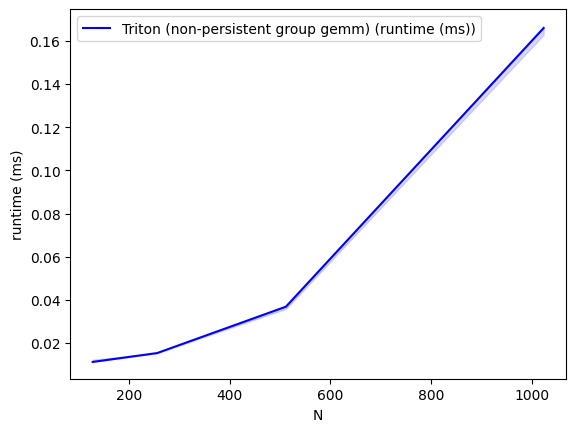

non-persistent-group-gemm-square:
        N  Triton (non-persistent group gemm) (runtime (ms))
0   128.0                                           0.011264
1   256.0                                           0.015360
2   512.0                                           0.036864
3  1024.0                                           0.165888


In [6]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"],
        x_vals=WORKLOAD_NS,                       # 128, 256, 512, 1024
        line_arg="provider",
        line_vals=["triton"],
        line_names=["Triton (non-persistent group gemm)"],
        styles=[("blue", "-")],
        ylabel="runtime (ms)",
        plot_name="non-persistent-group-gemm-square",
        args={},
    )
)
def benchmark_non_persistent(N, provider):
    group_size = WORKLOAD_GROUP_SIZE
    gA, gB = _make_group([N] * group_size, [N] * group_size, [N] * group_size)

    cfg = best_cfg_by_N[N]
    BM, BN, BK = cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"], cfg["BLOCK_SIZE_K"]
    NW, NS = cfg["num_warps"], cfg["num_stages"]

    args = _prepare_launch_args(gA, gB, BM, BN)
    quantiles = [0.5, 0.2, 0.8]
    return triton.testing.do_bench(
        lambda: _launch(args, BM, BN, BK, NW, NS),
        quantiles=quantiles,
    )


benchmark_non_persistent.run(show_plots=True, print_data=True)


### Persistent group GEMM

In [7]:
@triton.jit
def persistent_group_gemm(
    group_a_ptrs,            # [G]   int64 base addresses of A_g
    group_b_ptrs,            # [G]
    group_c_ptrs,            # [G]
    group_gemm_sizes_ptr,    # [G, 3] (M_g, N_g, K_g)
    g_lds_ptr,               # [G, 3] (lda_g, ldb_g, ldc_g)
    group_size,
    NUM_SMS: tl.constexpr,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
):
    block_id = tl.program_id(0)

    # Each CTA walks all groups in order; within a group it claims every
    # NUM_SMS-th (M, N) tile starting from `block_id`. All CTAs finish group g
    # before moving on to g+1 — load-imbalanced when group sizes vary.
    for g in tl.range(group_size):
        local_a_ptr = tl.load(group_a_ptrs + g).to(tl.pointer_type(tl.bfloat16))
        local_b_ptr = tl.load(group_b_ptrs + g).to(tl.pointer_type(tl.bfloat16))
        local_c_ptr = tl.load(group_c_ptrs + g).to(tl.pointer_type(tl.bfloat16))

        m = tl.load(group_gemm_sizes_ptr + g * 3)
        n = tl.load(group_gemm_sizes_ptr + g * 3 + 1)
        k = tl.load(group_gemm_sizes_ptr + g * 3 + 2)

        lda = tl.load(g_lds_ptr + g * 3)
        ldb = tl.load(g_lds_ptr + g * 3 + 1)
        ldc = tl.load(g_lds_ptr + g * 3 + 2)

        num_tiles_m = tl.cdiv(m, BLOCK_SIZE_M)
        num_tiles_n = tl.cdiv(n, BLOCK_SIZE_N)
        num_tiles = num_tiles_m * num_tiles_n

        offs_k = tl.arange(0, BLOCK_SIZE_K)

        for tile_id in tl.range(block_id, num_tiles, NUM_SMS):
            tile_m_idx = tile_id // num_tiles_n
            tile_n_idx = tile_id % num_tiles_n

            m_offs = tile_m_idx * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
            n_offs = tile_n_idx * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)

            accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
            for k_start in range(0, k, BLOCK_SIZE_K):
                k_offs = k_start + offs_k
                k_mask = k_offs < k
                a_mask = (m_offs[:, None] < m) & k_mask[None, :]
                b_mask = k_mask[:, None] & (n_offs[None, :] < n)
                a_tile = tl.load(
                    local_a_ptr + m_offs[:, None] * lda + k_offs[None, :],
                    mask=a_mask, other=0.0,
                )
                b_tile = tl.load(
                    local_b_ptr + k_offs[:, None] * ldb + n_offs[None, :],
                    mask=b_mask, other=0.0,
                )
                accumulator = tl.dot(a_tile, b_tile, acc=accumulator)

            c_mask = (m_offs[:, None] < m) & (n_offs[None, :] < n)
            tl.store(
                local_c_ptr + m_offs[:, None] * ldc + n_offs[None, :],
                accumulator.to(tl.bfloat16),
                mask=c_mask,
            )

#### Wrapper

Notice that the kernel signature dropped `group_prefix_blks_ptr` — there's no prefix sum to compute on the host, and the grid is fixed at `(NUM_SMS,)`. That makes this wrapper noticeably simpler than `non_persistent_group_gemm_fn`, and it means the persistent kernel is a clean fit for `@triton.autotune` (the meta-parameters no longer affect the launch grid).

In [8]:
def persistent_group_gemm_fn(
    group_A,
    group_B,
    BLOCK_SIZE_M: int = 64,
    BLOCK_SIZE_N: int = 64,
    BLOCK_SIZE_K: int = 32,
    num_warps: int = 4,
    num_stages: int = 3,
):
    """Dispatch wrapper for the basic persistent group GEMM kernel."""
    assert len(group_A) == len(group_B)
    G = len(group_A)
    DEVICE = group_A[0].device
    NUM_SMS = torch.cuda.get_device_properties(DEVICE).multi_processor_count

    A_addrs, B_addrs, C_addrs = [], [], []
    g_sizes, g_lds = [], []
    group_C = []

    for A, B in zip(group_A, group_B):
        assert A.shape[1] == B.shape[0], f"K mismatch: {A.shape} vs {B.shape}"
        M, K = A.shape
        _, N = B.shape
        C = torch.empty((M, N), device=DEVICE, dtype=A.dtype)
        group_C.append(C)
        A_addrs.append(A.data_ptr())
        B_addrs.append(B.data_ptr())
        C_addrs.append(C.data_ptr())
        g_sizes += [M, N, K]
        g_lds += [A.stride(0), B.stride(0), C.stride(0)]

    d_a_ptrs = torch.tensor(A_addrs, device=DEVICE, dtype=torch.int64)
    d_b_ptrs = torch.tensor(B_addrs, device=DEVICE, dtype=torch.int64)
    d_c_ptrs = torch.tensor(C_addrs, device=DEVICE, dtype=torch.int64)
    d_g_sizes = torch.tensor(g_sizes, device=DEVICE, dtype=torch.int32)
    d_g_lds = torch.tensor(g_lds, device=DEVICE, dtype=torch.int32)

    persistent_group_gemm[(NUM_SMS,)](
        d_a_ptrs, d_b_ptrs, d_c_ptrs,
        d_g_sizes, d_g_lds,
        G,
        NUM_SMS=NUM_SMS,
        BLOCK_SIZE_M=BLOCK_SIZE_M,
        BLOCK_SIZE_N=BLOCK_SIZE_N,
        BLOCK_SIZE_K=BLOCK_SIZE_K,
        num_warps=num_warps,
        num_stages=num_stages,
    )
    return group_C


#### Correctness check

In [9]:
def _check(fn, group_A, group_B, label, atol=2e-2, rtol=2e-2):
    """Generic correctness check — `fn(group_A, group_B) -> list[Tensor]`."""
    tri_out = fn(group_A, group_B)
    ref_out = [torch.matmul(a.float(), b.float()).to(a.dtype)
               for a, b in zip(group_A, group_B)]
    for t, r in zip(tri_out, ref_out):
        torch.testing.assert_close(t, r, atol=atol, rtol=rtol)
    print(f"[{label}] OK ({len(group_A)} problems)")


#### Correctness — basic persistent on diverse workloads

In [10]:
torch.manual_seed(0)

WORKLOADS = [
    # label,           ms,                    ns,                    ks
    ("aligned",        [1024, 512, 256, 128], [1024, 512, 256, 128], [1024, 512, 256, 128]),
    ("irregular",      [1000, 513, 200, 99 ], [1000, 257, 200, 99 ], [1000, 513, 200, 99 ]),
    ("mixed",          [1024, 512, 256, 128], [99,   257, 200, 17 ], [1024, 512, 256, 128]),
    ("heterogeneous",  [2048, 64,  1024, 7 ], [2048, 64,  1024, 7 ], [2048, 64,  1024, 7 ]),
]

for label, ms, ns, ks in WORKLOADS:
    gA, gB = _make_group(ms, ns, ks)
    _check(persistent_group_gemm_fn, gA, gB, f"basic / {label}")


[basic / aligned] OK (4 problems)
[basic / irregular] OK (4 problems)
[basic / mixed] OK (4 problems)
[basic / heterogeneous] OK (4 problems)


#### Autotune persistent kernels — per workload

Same per-workload sweep approach as the non-persistent autotune: each kernel is tuned **independently for every `N` in `WORKLOAD_NS`**, and the winning config is stored in a dict keyed by `N`. The final benchmark then looks up the config that matches the workload it's measuring.

One nice property of the persistent kernels: the launch grid is fixed at `(NUM_SMS,)` regardless of `(BM, BN)`, so we don't need to rebuild any device-side metadata between configs — `_prepare_persistent_args` runs once per workload and is reused across the whole config sweep. We also add `NUM_SMS` itself as a tuning axis (`{84, device_num_sms, 128}`), because for the persistent kernels the right grid size depends on the workload.


In [11]:
def _prepare_persistent_args(group_A, group_B):
    """Build device-side metadata for the persistent kernels.

    Independent of (BM, BN, NUM_SMS) — the launch grid is decided at call
    time, not by output shape.
    """
    G = len(group_A)
    DEVICE = group_A[0].device

    A_addrs, B_addrs, C_addrs = [], [], []
    g_sizes, g_lds = [], []
    group_C = []
    all_K_div_16, all_N_div_16 = True, True

    for A, B in zip(group_A, group_B):
        M, K = A.shape
        _, N = B.shape
        C = torch.empty((M, N), device=DEVICE, dtype=A.dtype)
        group_C.append(C)
        A_addrs.append(A.data_ptr())
        B_addrs.append(B.data_ptr())
        C_addrs.append(C.data_ptr())
        g_sizes += [M, N, K]
        g_lds += [A.stride(0), B.stride(0), C.stride(0)]
        all_K_div_16 &= (K % 16 == 0)
        all_N_div_16 &= (N % 16 == 0)

    return dict(
        d_a_ptrs=torch.tensor(A_addrs, device=DEVICE, dtype=torch.int64),
        d_b_ptrs=torch.tensor(B_addrs, device=DEVICE, dtype=torch.int64),
        d_c_ptrs=torch.tensor(C_addrs, device=DEVICE, dtype=torch.int64),
        d_g_sizes=torch.tensor(g_sizes, device=DEVICE, dtype=torch.int32),
        d_g_lds=torch.tensor(g_lds, device=DEVICE, dtype=torch.int32),
        G=G,
        all_K_div_16=all_K_div_16,
        all_N_div_16=all_N_div_16,
        group_C=group_C,
    )


def _launch_persistent(args, BM, BN, BK, num_warps, num_stages, NUM_SMS):
    persistent_group_gemm[(NUM_SMS,)](
        args["d_a_ptrs"], args["d_b_ptrs"], args["d_c_ptrs"],
        args["d_g_sizes"], args["d_g_lds"],
        args["G"],
        NUM_SMS=NUM_SMS,
        BLOCK_SIZE_M=BM, BLOCK_SIZE_N=BN, BLOCK_SIZE_K=BK,
        num_warps=num_warps, num_stages=num_stages,
    )


DEVICE_NUM_SMS = torch.cuda.get_device_properties(torch.device("cuda")).multi_processor_count
NUM_SMS_CANDIDATES = sorted({84, DEVICE_NUM_SMS, 128})

PERSISTENT_AUTOTUNE_CONFIGS = [
    {**cfg, "NUM_SMS": ns}
    for cfg in AUTOTUNE_CONFIGS
    for ns in NUM_SMS_CANDIDATES
]


def _sweep_persistent_per_workload(launcher, label, **launcher_kwargs):
    """Sweep PERSISTENT_AUTOTUNE_CONFIGS for each N in WORKLOAD_NS.

    Returns dict[N] -> best config. Extra launcher kwargs (e.g. COMPILE_OPT)
    are forwarded to the launcher unchanged.
    """
    print(f"Sweeping {len(PERSISTENT_AUTOTUNE_CONFIGS)} configs x "
          f"{len(WORKLOAD_NS)} workloads for {label}  "
          f"(NUM_SMS in {NUM_SMS_CANDIDATES}, device has {DEVICE_NUM_SMS})...")
    best_by_N = {}
    for N in WORKLOAD_NS:
        gA, gB = _make_group([N] * WORKLOAD_GROUP_SIZE,
                             [N] * WORKLOAD_GROUP_SIZE,
                             [N] * WORKLOAD_GROUP_SIZE)
        args = _prepare_persistent_args(gA, gB)
        results = []
        for cfg in PERSISTENT_AUTOTUNE_CONFIGS:
            BM, BN = cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"]
            BK, NW, NS = cfg["BLOCK_SIZE_K"], cfg["num_warps"], cfg["num_stages"]
            SM = cfg["NUM_SMS"]
            try:
                ms = triton.testing.do_bench(
                    lambda: launcher(args, BM, BN, BK, NW, NS, SM,
                                     **launcher_kwargs),
                    warmup=25, rep=100,
                )
                results.append((ms, cfg))
            except Exception as e:
                results.append((float("inf"), cfg, str(e)))
        results.sort(key=lambda x: x[0])
        best_ms, best_cfg, *_ = results[0]
        best_by_N[N] = best_cfg
        print(f"  N={N:4d}: best {best_ms:.4f} ms  "
              f"BM={best_cfg['BLOCK_SIZE_M']:3d} BN={best_cfg['BLOCK_SIZE_N']:3d} "
              f"BK={best_cfg['BLOCK_SIZE_K']:3d} NUM_SMS={best_cfg['NUM_SMS']:3d} "
              f"W={best_cfg['num_warps']} S={best_cfg['num_stages']}")
    return best_by_N


torch.manual_seed(0)
best_persistent_cfg_by_N = _sweep_persistent_per_workload(
    _launch_persistent, "persistent (basic)")


Sweeping 96 configs x 4 workloads for persistent (basic)  (NUM_SMS in [84, 108, 128], device has 108)...
  N= 128: best 0.0223 ms  BM= 64 BN= 64 BK= 64 NUM_SMS= 84 W=8 S=4
  N= 256: best 0.0345 ms  BM= 64 BN= 64 BK= 64 NUM_SMS= 84 W=8 S=3
  N= 512: best 0.0604 ms  BM= 64 BN= 64 BK= 64 NUM_SMS= 84 W=8 S=4
  N=1024: best 0.2241 ms  BM= 64 BN=128 BK= 64 NUM_SMS=128 W=4 S=4


#### Better Persistent Scheduling

The basic persistent kernel uses **per-group** scheduling: each CTA's tile index resets to `block_id` at the start of every group, so a CTA with `block_id >= num_tiles_g` does no work in group `g`.

**Limitation**: when `num_tiles_per_group < NUM_SMS`, high-numbered CTAs idle for the whole kernel run. With 4 groups of 3 tiles each and `NUM_SMS = 5`:

```
              g=0  g=1  g=2  g=3
       t=0 |  0  |  0  |  0  |  0  |    CTA 0 does 4 tiles
       t=1 |  1  |  1  |  1  |  1  |    CTA 1 does 4 tiles
       t=2 |  2  |  2  |  2  |  2  |    CTA 2 does 4 tiles
                                        CTAs 3, 4 do 0 tiles (idle)
```

Three CTAs do 4 tiles each in sequence; the other two SMs are wasted. Max work = 4 tile-times.

The fix is a **flat tile-space** schedule: keep `global_tile_idx` monotonic across groups. Treat the union of all groups' tiles as one flat sequence of length `sum(num_tiles_g)`; each CTA walks it by stride `NUM_SMS`. After processing a tile in group `g`, advance by `NUM_SMS` — if the new index lands past group `g`'s range, the inner while-loop exits and group `g+1` picks up wherever `global_tile_idx` is. Same total work, but spread across all CTAs:

```
              g=0  g=1  g=2  g=3
       t=0 |  0  |  3  |  1  |  4  |    every CTA gets work
       t=1 |  1  |  4  |  2  |  0  |    max work = 3 tiles
       t=2 |  2  |  0  |  3  |  1  |
```

All 5 SMs busy → wall time 3 tile-times instead of 4. Same code in the inner tile body — only the outer scheduling loop differs.

In [12]:
@triton.jit
def persistent_group_gemm_schedule(
    group_a_ptrs,            # [G]   int64 base addresses of A_g
    group_b_ptrs,            # [G]
    group_c_ptrs,            # [G]
    group_gemm_sizes_ptr,    # [G, 3] (M_g, N_g, K_g)
    g_lds_ptr,               # [G, 3] (lda_g, ldb_g, ldc_g)
    group_size,
    NUM_SMS: tl.constexpr,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    COMPILE_OPT: tl.constexpr,
):
    """Flat tile-space persistent group GEMM.

    `COMPILE_OPT` (constexpr): when True, applies `tl.multiple_of(_, [16, 16])`
    hints to the A/B/C pointer tensors in the inner loop. The wrapper sets
    this to True only when every (lda, ldb, ldc) in the batch is a multiple
    of 16 — otherwise the hint would be a false promise and could cause
    misaligned vector loads / undefined behavior.
    """
    block_id = tl.program_id(0)

    # Flat tile-space schedule: global_tile_idx monotonic across groups.
    global_tile_idx = block_id
    global_group_start_tile_idx = 0

    for g in range(group_size):
        local_a_ptr = tl.load(group_a_ptrs + g).to(tl.pointer_type(tl.bfloat16))
        local_b_ptr = tl.load(group_b_ptrs + g).to(tl.pointer_type(tl.bfloat16))
        local_c_ptr = tl.load(group_c_ptrs + g).to(tl.pointer_type(tl.bfloat16))

        m = tl.load(group_gemm_sizes_ptr + g * 3)
        n = tl.load(group_gemm_sizes_ptr + g * 3 + 1)
        k = tl.load(group_gemm_sizes_ptr + g * 3 + 2)

        lda = tl.load(g_lds_ptr + g * 3)
        ldb = tl.load(g_lds_ptr + g * 3 + 1)
        ldc = tl.load(g_lds_ptr + g * 3 + 2)

        num_tiles_m = tl.cdiv(m, BLOCK_SIZE_M)
        num_tiles_n = tl.cdiv(n, BLOCK_SIZE_N)
        num_tiles = num_tiles_m * num_tiles_n
        global_group_end_tile_idx = global_group_start_tile_idx + num_tiles

        while global_tile_idx < global_group_end_tile_idx:
            local_tile_idx = global_tile_idx - global_group_start_tile_idx
            local_tile_m = local_tile_idx // num_tiles_n
            local_tile_n = local_tile_idx % num_tiles_n

            offs_m = local_tile_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
            offs_n = local_tile_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)

            accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
            for k_start in range(0, k, BLOCK_SIZE_K):
                offs_k = k_start + tl.arange(0, BLOCK_SIZE_K)
                k_mask = offs_k < k
                a_mask = (offs_m[:, None] < m) & k_mask[None, :]
                b_mask = k_mask[:, None] & (offs_n[None, :] < n)

                a_ptrs = local_a_ptr + offs_m[:, None] * lda + offs_k[None, :]
                b_ptrs = local_b_ptr + offs_k[:, None] * ldb + offs_n[None, :]
                if COMPILE_OPT:
                    tl.multiple_of(a_ptrs, [16, 16])
                    tl.multiple_of(b_ptrs, [16, 16])

                a_tile = tl.load(a_ptrs, mask=a_mask, other=0.0)
                b_tile = tl.load(b_ptrs, mask=b_mask, other=0.0)
                accumulator = tl.dot(a_tile, b_tile, acc=accumulator)

            c_ptrs = local_c_ptr + offs_m[:, None] * ldc + offs_n[None, :]
            if COMPILE_OPT:
                tl.multiple_of(c_ptrs, [16, 16])
            c_mask = (offs_m[:, None] < m) & (offs_n[None, :] < n)
            tl.store(c_ptrs, accumulator.to(tl.bfloat16), mask=c_mask)

            global_tile_idx += NUM_SMS

        global_group_start_tile_idx += num_tiles


#### Wrapper

In [13]:
def persistent_group_gemm_schedule_fn(
    group_A,
    group_B,
    BLOCK_SIZE_M: int = 64,
    BLOCK_SIZE_N: int = 64,
    BLOCK_SIZE_K: int = 32,
    num_warps: int = 4,
    num_stages: int = 3,
    NUM_SMS: int = None,
    compile_opt: bool = True,
):
    """Wrapper for the flat-tile-space persistent kernel.

    `compile_opt=True` requests the `tl.multiple_of(_, [16, 16])` hints —
    but it's only honored if every (lda, ldb, ldc) in the batch is a
    multiple of 16. Otherwise we silently fall back to no hint (so the
    wrapper is safe to call on any shape)."""
    assert len(group_A) == len(group_B)
    G = len(group_A)
    DEVICE = group_A[0].device
    if NUM_SMS is None:
        NUM_SMS = torch.cuda.get_device_properties(DEVICE).multi_processor_count

    A_addrs, B_addrs, C_addrs = [], [], []
    g_sizes, g_lds = [], []
    group_C = []
    all_strides_div_16 = True
    for A, B in zip(group_A, group_B):
        assert A.shape[1] == B.shape[0]
        M, K = A.shape
        _, N = B.shape
        C = torch.empty((M, N), device=DEVICE, dtype=A.dtype)
        group_C.append(C)
        A_addrs.append(A.data_ptr())
        B_addrs.append(B.data_ptr())
        C_addrs.append(C.data_ptr())
        g_sizes += [M, N, K]
        lda_g, ldb_g, ldc_g = A.stride(0), B.stride(0), C.stride(0)
        g_lds += [lda_g, ldb_g, ldc_g]
        if (lda_g % 16) or (ldb_g % 16) or (ldc_g % 16):
            all_strides_div_16 = False

    use_compile_opt = compile_opt and all_strides_div_16

    d_a_ptrs = torch.tensor(A_addrs, device=DEVICE, dtype=torch.int64)
    d_b_ptrs = torch.tensor(B_addrs, device=DEVICE, dtype=torch.int64)
    d_c_ptrs = torch.tensor(C_addrs, device=DEVICE, dtype=torch.int64)
    d_g_sizes = torch.tensor(g_sizes, device=DEVICE, dtype=torch.int32)
    d_g_lds = torch.tensor(g_lds, device=DEVICE, dtype=torch.int32)

    persistent_group_gemm_schedule[(NUM_SMS,)](
        d_a_ptrs, d_b_ptrs, d_c_ptrs,
        d_g_sizes, d_g_lds,
        G,
        NUM_SMS=NUM_SMS,
        BLOCK_SIZE_M=BLOCK_SIZE_M,
        BLOCK_SIZE_N=BLOCK_SIZE_N,
        BLOCK_SIZE_K=BLOCK_SIZE_K,
        COMPILE_OPT=use_compile_opt,
        num_warps=num_warps,
        num_stages=num_stages,
    )
    return group_C


def _launch_persistent_schedule(args, BM, BN, BK, num_warps, num_stages,
                                 NUM_SMS, COMPILE_OPT=False):
    persistent_group_gemm_schedule[(NUM_SMS,)](
        args["d_a_ptrs"], args["d_b_ptrs"], args["d_c_ptrs"],
        args["d_g_sizes"], args["d_g_lds"],
        args["G"],
        NUM_SMS=NUM_SMS,
        BLOCK_SIZE_M=BM, BLOCK_SIZE_N=BN, BLOCK_SIZE_K=BK,
        COMPILE_OPT=COMPILE_OPT,
        num_warps=num_warps, num_stages=num_stages,
    )


#### Correctness

In [14]:
torch.manual_seed(0)

for label, ms, ns, ks in WORKLOADS:
    gA, gB = _make_group(ms, ns, ks)
    # Default: compile_opt=True. Wrapper silently disables it if strides
    # aren't 16-aligned, so all four workloads must still pass.
    _check(persistent_group_gemm_schedule_fn, gA, gB, f"schedule (auto) / {label}")
    # Force compile_opt=False to also verify the no-hint path:
    _check(
        lambda a, b: persistent_group_gemm_schedule_fn(a, b, compile_opt=False),
        gA, gB,
        f"schedule (compile_opt=False) / {label}",
    )


[schedule (auto) / aligned] OK (4 problems)
[schedule (compile_opt=False) / aligned] OK (4 problems)
[schedule (auto) / irregular] OK (4 problems)
[schedule (compile_opt=False) / irregular] OK (4 problems)
[schedule (auto) / mixed] OK (4 problems)
[schedule (compile_opt=False) / mixed] OK (4 problems)
[schedule (auto) / heterogeneous] OK (4 problems)
[schedule (compile_opt=False) / heterogeneous] OK (4 problems)


#### Autotune

In [15]:
torch.manual_seed(0)

best_persistent_schedule_cfg_by_N = _sweep_persistent_per_workload(
    _launch_persistent_schedule, "schedule (COMPILE_OPT=False)",
    COMPILE_OPT=False,
)
best_persistent_schedule_co_cfg_by_N = _sweep_persistent_per_workload(
    _launch_persistent_schedule, "schedule (COMPILE_OPT=True)",
    COMPILE_OPT=True,
)


Sweeping 96 configs x 4 workloads for schedule (COMPILE_OPT=False)  (NUM_SMS in [84, 108, 128], device has 108)...
  N= 128: best 0.0112 ms  BM= 64 BN= 64 BK= 64 NUM_SMS= 84 W=8 S=3
  N= 256: best 0.0149 ms  BM= 64 BN= 64 BK= 64 NUM_SMS=128 W=8 S=3
  N= 512: best 0.0383 ms  BM= 64 BN=128 BK= 32 NUM_SMS=128 W=4 S=4
  N=1024: best 0.1715 ms  BM=128 BN=128 BK= 64 NUM_SMS=108 W=8 S=4
Sweeping 96 configs x 4 workloads for schedule (COMPILE_OPT=True)  (NUM_SMS in [84, 108, 128], device has 108)...
  N= 128: best 0.0126 ms  BM= 64 BN= 64 BK= 64 NUM_SMS= 84 W=4 S=4
  N= 256: best 0.0171 ms  BM= 64 BN= 64 BK= 64 NUM_SMS=128 W=4 S=4
  N= 512: best 0.0404 ms  BM= 64 BN=128 BK= 64 NUM_SMS=128 W=4 S=3
  N=1024: best 0.1909 ms  BM=128 BN=128 BK= 64 NUM_SMS=128 W=4 S=3


### Benchmark — final 4-kernel comparison

Same axes as 08-grouped-gemm's `benchmark_square_matrices` for direct comparison: `N in {128, 256, 512, 1024}`, `group_size = 4`, square `N x N x N` matrices, runtime in ms (lower = better).

**Per-workload autotuning:** each kernel was tuned independently for every `N` in `WORKLOAD_NS` in the autotune cells above; the benchmark below looks up `best_*_cfg_by_N[N]` for each point. This is what 08-grouped-gemm's `@triton.autotune` does implicitly (key=`['group_size']`, but with the kernel's own runtime cache hitting the actual `(M, N, K)` shapes via specialization). Without the per-workload lookup, the line for each kernel reflects a single compromise config rather than the kernel's actual peak at each size.

Four kernels, in order of optimizations applied:
1. **non-persistent** — baseline, one CTA per output tile
2. **persistent (basic)** — fixed `NUM_SMS` grid, per-group scheduling
3. **persistent + flat schedule** — flat tile-space schedule across groups (loads spread across all SMs)
4. **persistent + flat schedule + compile_opt** — same as 3, plus `tl.multiple_of` hints on the pointer tensors


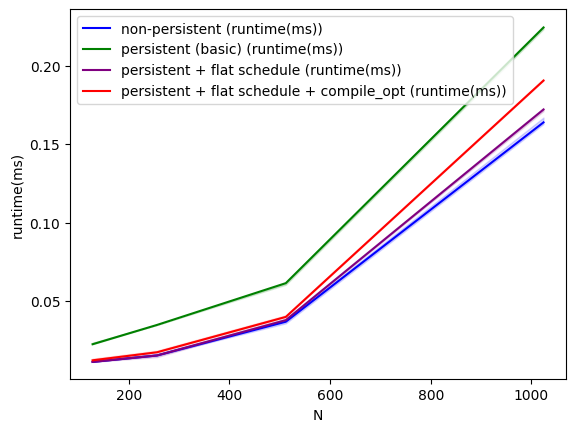

group-gemm-4kernel-runtime:
        N  non-persistent (runtime(ms))  persistent (basic) (runtime(ms))  persistent + flat schedule (runtime(ms))  persistent + flat schedule + compile_opt (runtime(ms))
0   128.0                      0.011264                          0.022528                                  0.011264                                                0.012288
1   256.0                      0.015360                          0.034816                                  0.015360                                                0.017408
2   512.0                      0.036864                          0.061440                                  0.037888                                                0.039936
3  1024.0                      0.163840                          0.224256                                  0.172032                                                0.190464


In [16]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"],
        x_vals=WORKLOAD_NS,                       # 128, 256, 512, 1024
        line_arg="provider",
        line_vals=["non_persistent",
                   "persistent",
                   "persistent_schedule",
                   "persistent_schedule_comp"],
        line_names=["non-persistent",
                    "persistent (basic)",
                    "persistent + flat schedule",
                    "persistent + flat schedule + compile_opt"],
        styles=[("blue", "-"), ("green", "-"), ("purple", "-"), ("red", "-")],
        ylabel="runtime(ms)",
        plot_name="group-gemm-4kernel-runtime",
        args={},
    )
)
def benchmark_four(N, provider):
    group_size = WORKLOAD_GROUP_SIZE
    gA, gB = _make_group([N] * group_size, [N] * group_size, [N] * group_size)
    quantiles = [0.5, 0.2, 0.8]

    if provider == "non_persistent":
        cfg = best_cfg_by_N[N]
        args = _prepare_launch_args(gA, gB,
                                    cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"])
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: _launch(args,
                            cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"],
                            cfg["BLOCK_SIZE_K"],
                            cfg["num_warps"], cfg["num_stages"]),
            quantiles=quantiles,
        )

    elif provider == "persistent":
        cfg = best_persistent_cfg_by_N[N]
        args = _prepare_persistent_args(gA, gB)
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: _launch_persistent(
                args, cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"], cfg["BLOCK_SIZE_K"],
                cfg["num_warps"], cfg["num_stages"], cfg["NUM_SMS"]),
            quantiles=quantiles,
        )

    elif provider == "persistent_schedule":
        cfg = best_persistent_schedule_cfg_by_N[N]
        args = _prepare_persistent_args(gA, gB)
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: _launch_persistent_schedule(
                args, cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"], cfg["BLOCK_SIZE_K"],
                cfg["num_warps"], cfg["num_stages"], cfg["NUM_SMS"],
                COMPILE_OPT=False),
            quantiles=quantiles,
        )

    elif provider == "persistent_schedule_comp":
        cfg = best_persistent_schedule_co_cfg_by_N[N]
        args = _prepare_persistent_args(gA, gB)
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: _launch_persistent_schedule(
                args, cfg["BLOCK_SIZE_M"], cfg["BLOCK_SIZE_N"], cfg["BLOCK_SIZE_K"],
                cfg["num_warps"], cfg["num_stages"], cfg["NUM_SMS"],
                COMPILE_OPT=True),
            quantiles=quantiles,
        )

    return ms, min_ms, max_ms


benchmark_four.run(show_plots=True, print_data=True)
